In [1]:
import json
import math
from io import BytesIO
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PolyCollection

CSV_PATH = Path("wifi_samples.csv")
TILE_SIZE = 256
USER_AGENT = "stats305c-eda/1.0"
WDUTIL_RSSI_PLACEHOLDER_FILL_DBM = None
COORDINATE_PRIORITY = ("phone_gps", "mac_corelocation", "corelocation")
COORDINATE_LABELS = {
    "phone_gps": "phone GPS",
    "mac_corelocation": "mac CoreLocation",
    "corelocation": "legacy CoreLocation",
}
DATAFRAME_COLUMNS = [
    "measurement_set_id",
    "sample_index",
    "collector_id",
    "building",
    "floor",
    "waypoint_id",
    "measurement_set_timestamp_utc",
    "location_timestamp",
    "latitude",
    "longitude",
    "h_accuracy_m",
    "mac_location_timestamp",
    "mac_latitude",
    "mac_longitude",
    "mac_h_accuracy_m",
    "phone_location_timestamp",
    "phone_latitude",
    "phone_longitude",
    "phone_altitude_m",
    "selected_location_source",
    "selected_location_timestamp",
    "selected_latitude",
    "selected_longitude",
    "wdutil_rssi_dbm",
    "wdutil_rssi_effective_dbm",
    "wdutil_noise_dbm",
    "wdutil_tx_rate",
    "wdutil_zero_placeholder",
]
NUMERIC_COLUMNS = [
    "sample_index",
    "floor",
    "latitude",
    "longitude",
    "h_accuracy_m",
    "mac_latitude",
    "mac_longitude",
    "mac_h_accuracy_m",
    "phone_latitude",
    "phone_longitude",
    "phone_altitude_m",
    "wdutil_rssi_dbm",
    "wdutil_noise_dbm",
]


def resolve_rssi_placeholder_fill_value(wifi_df):
    if WDUTIL_RSSI_PLACEHOLDER_FILL_DBM is not None:
        return float(WDUTIL_RSSI_PLACEHOLDER_FILL_DBM)
    observed = wifi_df.loc[
        wifi_df["wdutil_rssi_dbm"].notna() & wifi_df["wdutil_rssi_dbm"].ne(0),
        "wdutil_rssi_dbm",
    ]
    if observed.empty:
        raise ValueError("Could not infer an RSSI fill value because there are no nonzero wdutil_rssi_dbm values.")
    return float(observed.min())


def build_wifi_dataframe(csv_path=CSV_PATH):
    wifi_df = pd.read_csv(csv_path, na_values=["null", "none", "nan"], keep_default_na=True)

    for column in wifi_df.columns:
        if pd.api.types.is_object_dtype(wifi_df[column]) or pd.api.types.is_string_dtype(wifi_df[column]):
            wifi_df[column] = wifi_df[column].map(
                lambda value: value.strip() if isinstance(value, str) else value
            )
    wifi_df = wifi_df.replace(r"^\\s*$", pd.NA, regex=True)

    for column in NUMERIC_COLUMNS:
        if column in wifi_df.columns:
            wifi_df[column] = pd.to_numeric(wifi_df[column], errors="coerce")

    tx_rate_mbps = pd.to_numeric(
        wifi_df["wdutil_tx_rate"].astype("string").str.extract(r"([0-9.]+)", expand=False),
        errors="coerce",
    )
    wifi_df["wdutil_zero_placeholder"] = (
        wifi_df["wdutil_rssi_dbm"].ge(0)
        & wifi_df["wdutil_noise_dbm"].ge(0)
        & tx_rate_mbps.fillna(0).eq(0)
    )
    rssi_fill_value = resolve_rssi_placeholder_fill_value(wifi_df)
    wifi_df["wdutil_rssi_effective_dbm"] = wifi_df["wdutil_rssi_dbm"]
    wifi_df.loc[wifi_df["wdutil_zero_placeholder"], "wdutil_rssi_effective_dbm"] = rssi_fill_value
    wifi_df.attrs["wdutil_rssi_placeholder_fill_dbm"] = rssi_fill_value

    phone_available = wifi_df["phone_latitude"].notna() & wifi_df["phone_longitude"].notna()
    mac_available = wifi_df["mac_latitude"].notna() & wifi_df["mac_longitude"].notna()
    core_available = wifi_df["latitude"].notna() & wifi_df["longitude"].notna()

    wifi_df["selected_location_source"] = pd.Series(pd.NA, index=wifi_df.index, dtype="object")
    wifi_df.loc[phone_available, "selected_location_source"] = "phone_gps"
    wifi_df.loc[~phone_available & mac_available, "selected_location_source"] = "mac_corelocation"
    wifi_df.loc[
        ~phone_available & ~mac_available & core_available,
        "selected_location_source",
    ] = "corelocation"

    wifi_df["selected_location_timestamp"] = (
        wifi_df["phone_location_timestamp"]
        .combine_first(wifi_df["mac_location_timestamp"])
        .combine_first(wifi_df["location_timestamp"])
    )
    wifi_df["selected_latitude"] = (
        wifi_df["phone_latitude"]
        .combine_first(wifi_df["mac_latitude"])
        .combine_first(wifi_df["latitude"])
    )
    wifi_df["selected_longitude"] = (
        wifi_df["phone_longitude"]
        .combine_first(wifi_df["mac_longitude"])
        .combine_first(wifi_df["longitude"])
    )

    return wifi_df.reindex(columns=DATAFRAME_COLUMNS)


def write_wifi_dataframe(wifi_df, output_path):
    output_path = Path(output_path)
    wifi_df.to_csv(output_path, index=False, na_rep="null")
    return output_path


def summarize_coordinate_sources(wifi_df):
    counts = wifi_df["selected_location_source"].value_counts(dropna=False)
    parts = []
    for source in COORDINATE_PRIORITY:
        count = int(counts.get(source, 0))
        if count:
            parts.append(f"{count} {COORDINATE_LABELS[source]}")
    missing = int(wifi_df["selected_location_source"].isna().sum())
    if missing:
        parts.append(f"{missing} missing coordinates")
    return ", ".join(parts)


def first_non_null(series, fallback="unknown"):
    non_null = series.dropna()
    return non_null.iloc[0] if not non_null.empty else fallback


def lonlat_to_world(lon, lat, zoom):
    scale = TILE_SIZE * (2 ** zoom)
    x = (lon + 180.0) / 360.0 * scale
    lat = max(min(lat, 85.05112878), -85.05112878)
    lat_rad = math.radians(lat)
    y = (1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * scale
    return x, y


def padded_bounds(lons, lats, pad_fraction=0.18, min_pad=0.0007):
    lon_min, lon_max = min(lons), max(lons)
    lat_min, lat_max = min(lats), max(lats)
    lon_pad = max(min_pad, (lon_max - lon_min) * pad_fraction)
    lat_pad = max(min_pad, (lat_max - lat_min) * pad_fraction)
    return lon_min - lon_pad, lat_min - lat_pad, lon_max + lon_pad, lat_max + lat_pad


def choose_zoom(lons, lats, max_tiles=20, min_zoom=14, max_zoom=19):
    bounds = padded_bounds(lons, lats)
    for zoom in range(max_zoom, min_zoom - 1, -1):
        left, top = lonlat_to_world(bounds[0], bounds[3], zoom)
        right, bottom = lonlat_to_world(bounds[2], bounds[1], zoom)
        x0 = math.floor(left / TILE_SIZE)
        x1 = math.floor(right / TILE_SIZE)
        y0 = math.floor(top / TILE_SIZE)
        y1 = math.floor(bottom / TILE_SIZE)
        tile_count = (x1 - x0 + 1) * (y1 - y0 + 1)
        if tile_count <= max_tiles:
            return zoom
    return min_zoom


def fetch_tile(x, y, zoom, timeout=5):
    max_index = 2 ** zoom - 1
    if x < 0 or y < 0 or x > max_index or y > max_index:
        raise ValueError("Tile outside valid range.")
    url = f"https://tile.openstreetmap.org/{zoom}/{x}/{y}.png"
    request = Request(url, headers={"User-Agent": USER_AGENT})
    with urlopen(request, timeout=timeout) as response:
        return mpimg.imread(BytesIO(response.read()), format="png")


def fetch_tile_mosaic(bounds, zoom):
    left, top = lonlat_to_world(bounds[0], bounds[3], zoom)
    right, bottom = lonlat_to_world(bounds[2], bounds[1], zoom)
    x0 = math.floor(left / TILE_SIZE)
    x1 = math.floor(right / TILE_SIZE)
    y0 = math.floor(top / TILE_SIZE)
    y1 = math.floor(bottom / TILE_SIZE)

    rows = []
    for y in range(y0, y1 + 1):
        row_tiles = [fetch_tile(x, y, zoom) for x in range(x0, x1 + 1)]
        rows.append(np.concatenate(row_tiles, axis=1))

    image = np.concatenate(rows, axis=0)
    extent = (x0 * TILE_SIZE, (x1 + 1) * TILE_SIZE, (y1 + 1) * TILE_SIZE, y0 * TILE_SIZE)
    return image, extent


def fetch_building_polygons(bounds, zoom, timeout=10):
    south, west, north, east = bounds[1], bounds[0], bounds[3], bounds[2]
    query = (
        "[out:json][timeout:20];"
        f"way[\\\"building\\\"]({south},{west},{north},{east});"
        "out geom;"
    )
    payload = urlencode({"data": query}).encode("utf-8")
    request = Request(
        "https://overpass-api.de/api/interpreter",
        data=payload,
        headers={
            "User-Agent": USER_AGENT,
            "Content-Type": "application/x-www-form-urlencoded",
        },
    )
    with urlopen(request, timeout=timeout) as response:
        data = json.loads(response.read().decode("utf-8"))

    polygons = []
    for element in data.get("elements", []):
        geometry = element.get("geometry") or []
        if len(geometry) < 3:
            continue
        polygons.append(
            [lonlat_to_world(node["lon"], node["lat"], zoom) for node in geometry]
        )
    return polygons


def aggregate_rssi_points(wifi_df):
    rssi_df = wifi_df.dropna(
        subset=["selected_latitude", "selected_longitude", "wdutil_rssi_effective_dbm"]
    ).copy()
    if rssi_df.empty:
        raise ValueError("No rows with selected coordinates and usable wdutil RSSI values were found.")

    rssi_df["label"] = rssi_df["waypoint_id"].fillna(rssi_df["building"]).fillna("unknown")
    grouped = (
        rssi_df.groupby(["selected_latitude", "selected_longitude"], as_index=False)
        .agg(
            mean_rssi_dbm=("wdutil_rssi_effective_dbm", "mean"),
            sample_count=("wdutil_rssi_effective_dbm", "size"),
            building=("building", first_non_null),
            label=("label", first_non_null),
        )
        .sort_values(["mean_rssi_dbm", "sample_count"], ignore_index=True)
    )
    return grouped


def plot_rssi_heatmap(wifi_df, zoom=None):
    points = aggregate_rssi_points(wifi_df)

    lons = points["selected_longitude"].tolist()
    lats = points["selected_latitude"].tolist()
    mean_rssi = points["mean_rssi_dbm"].to_numpy()
    bounds = padded_bounds(lons, lats)
    zoom = zoom or choose_zoom(lons, lats)

    fig, ax = plt.subplots(figsize=(12, 9))
    basemap_loaded = False

    try:
        image, extent = fetch_tile_mosaic(bounds, zoom)
        ax.imshow(image, extent=extent, origin="upper")
        basemap_loaded = True
    except Exception as exc:
        print(f"OSM tiles unavailable ({exc}). Falling back to a plain lat/lon heatmap.")

    if basemap_loaded:
        try:
            polygons = fetch_building_polygons(bounds, zoom)
        except Exception as exc:
            print(f"OSM building footprints unavailable ({exc}).")
            polygons = []
        if polygons:
            ax.add_collection(
                PolyCollection(
                    polygons,
                    facecolor=(1, 1, 1, 0.08),
                    edgecolor=(0, 0, 0, 0.55),
                    linewidth=0.8,
                )
            )

    if basemap_loaded:
        xs, ys = zip(
            *(lonlat_to_world(lon, lat, zoom) for lon, lat in zip(points["selected_longitude"], points["selected_latitude"]))
        )
    else:
        xs = points["selected_longitude"].to_numpy()
        ys = points["selected_latitude"].to_numpy()

    sizes = 70 + 14 * points["sample_count"].to_numpy()
    scatter = ax.scatter(
        xs,
        ys,
        c=mean_rssi,
        s=sizes,
        cmap="RdYlGn",
        alpha=0.92,
        edgecolors="black",
        linewidths=0.6,
        zorder=3,
    )
    colorbar = fig.colorbar(scatter, ax=ax, shrink=0.88)
    colorbar.set_label("Mean wdutil_rssi_dbm (dBm)")

    if basemap_loaded:
        left, top = lonlat_to_world(bounds[0], bounds[3], zoom)
        right, bottom = lonlat_to_world(bounds[2], bounds[1], zoom)
        ax.set_xlim(left, right)
        ax.set_ylim(bottom, top)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
    else:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(alpha=0.3)
        ax.set_aspect(1 / np.cos(np.deg2rad(np.mean(lats))))

    ax.set_title("Spatial heatmap of wdutil_rssi_dbm using phone-first coordinates")
    ax.text(
        0.01,
        0.01,
        f"Coordinate priority: phone GPS, then mac CoreLocation, then legacy CoreLocation. Zero-placeholder wdutil rows use {wifi_df.attrs['wdutil_rssi_placeholder_fill_dbm']:.1f} dBm. Marker size = sample count.",
        transform=ax.transAxes,
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
    )
    fig.tight_layout()
    return fig, ax, points


In [2]:
wifi_df = build_wifi_dataframe()
print(f"Loaded {len(wifi_df)} rows into pandas.DataFrame with {wifi_df.shape[1]} columns.")
print("Coordinate priority for selected_location_* columns: phone GPS -> mac CoreLocation -> legacy CoreLocation")
print(
    f"Using {wifi_df.attrs['wdutil_rssi_placeholder_fill_dbm']:.1f} dBm as the heatmap fill value for {int(wifi_df['wdutil_zero_placeholder'].sum())} wdutil zero-placeholder rows."
)
print(f"Selected coordinate coverage: {summarize_coordinate_sources(wifi_df)}.")
display(wifi_df.head(12))


Loaded 978 rows into pandas.DataFrame with 28 columns.
Coordinate priority for selected_location_* columns: phone GPS -> mac CoreLocation -> legacy CoreLocation
Using -128.0 dBm as the heatmap fill value for 54 wdutil zero-placeholder rows.
Selected coordinate coverage: 582 phone GPS, 273 mac CoreLocation, 96 legacy CoreLocation, 27 missing coordinates.


,measurement_set_id,sample_index,collector_id,building,floor,waypoint_id,measurement_set_timestamp_utc,location_timestamp,latitude,longitude,...,phone_altitude_m,selected_location_source,selected_location_timestamp,selected_latitude,selected_longitude,wdutil_rssi_dbm,wdutil_rssi_effective_dbm,wdutil_noise_dbm,wdutil_tx_rate,wdutil_zero_placeholder
0,c5c32855-1b84-45d9-86c6-20c26f40a728,0,kevin,evgr d,3,evgr d kevin room,2026-04-10T03:37:57.793334+00:00,2026-04-10 03:37:57 +0000,37.427721,-122.155860,...,NaN,corelocation,2026-04-10 03:37:57 +0000,37.427721,-122.155860,-58,-58,-98,173.0 Mbps,False
1,c5c32855-1b84-45d9-86c6-20c26f40a728,1,kevin,evgr d,3,evgr d kevin room,2026-04-10T03:37:57.793334+00:00,2026-04-10 03:37:57 +0000,37.427721,-122.155860,...,NaN,corelocation,2026-04-10 03:37:57 +0000,37.427721,-122.155860,-57,-57,-98,173.0 Mbps,False
2,c5c32855-1b84-45d9-86c6-20c26f40a728,2,kevin,evgr d,3,evgr d kevin room,2026-04-10T03:37:57.793334+00:00,2026-04-10 03:37:57 +0000,37.427721,-122.155860,...,NaN,corelocation,2026-04-10 03:37:57 +0000,37.427721,-122.155860,-57,-57,-98,173.0 Mbps,False
3,e88c9b05-6135-4ce1-a9fd-bfc79a0bda2d,0,kevin,evgr d,3,NaN,2026-04-10T03:39:47.036843+00:00,2026-04-10 03:39:47 +0000,37.427721,-122.155860,...,NaN,corelocation,2026-04-10 03:39:47 +0000,37.427721,-122.155860,-58,-58,-98,173.0 Mbps,False
4,e88c9b05-6135-4ce1-a9fd-bfc79a0bda2d,1,kevin,evgr d,3,NaN,2026-04-10T03:39:47.036843+00:00,2026-04-10 03:39:47 +0000,37.427721,-122.155860,...,NaN,corelocation,2026-04-10 03:39:47 +0000,37.427721,-122.155860,-58,-58,-98,173.0 Mbps,False
5,e88c9b05-6135-4ce1-a9fd-bfc79a0bda2d,2,kevin,evgr d,3,NaN,2026-04-10T03:39:47.036843+00:00,2026-04-10 03:39:47 +0000,37.427721,-122.155860,...,NaN,corelocation,2026-04-10 03:39:47 +0000,37.427721,-122.155860,-58,-58,-98,173.0 Mbps,False
6,821e7931-81e7-4b20-b0ee-2425f04eb925,0,kevin,evgr d,3,sequoia hall fyo,2026-04-10T19:29:18.700934+00:00,2026-04-10 19:29:18 +0000,37.428897,-122.172035,...,NaN,corelocation,2026-04-10 19:29:18 +0000,37.428897,-122.172035,-45,-45,-96,573.0 Mbps,False
7,821e7931-81e7-4b20-b0ee-2425f04eb925,1,kevin,evgr d,3,sequoia hall fyo,2026-04-10T19:29:18.700934+00:00,2026-04-10 19:29:18 +0000,37.428897,-122.172035,...,NaN,corelocation,2026-04-10 19:29:18 +0000,37.428897,-122.172035,-44,-44,-96,573.0 Mbps,False
8,821e7931-81e7-4b20-b0ee-2425f04eb925,2,kevin,evgr d,3,sequoia hall fyo,2026-04-10T19:29:18.700934+00:00,2026-04-10 19:29:18 +0000,37.428897,-122.172035,...,NaN,corelocation,2026-04-10 19:29:18 +0000,37.428897,-122.172035,-44,-44,-96,573.0 Mbps,False
9,b5760ea5-84ff-4ea9-a370-8306d5ab65f3,0,kevin,sequoia,2,sequoia fyo,2026-04-10T19:31:58.942286+00:00,2026-04-10 19:31:58 +0000,37.428971,-122.172236,...,NaN,corelocation,2026-04-10 19:31:58 +0000,37.428971,-122.172236,-44,-44,-96,573.0 Mbps,False


OSM building footprints unavailable (HTTP Error 400: Bad Request).
RSSI heatmap uses 254 unique coordinate bins from 951 rows with both selected coordinates and wdutil_rssi_dbm.


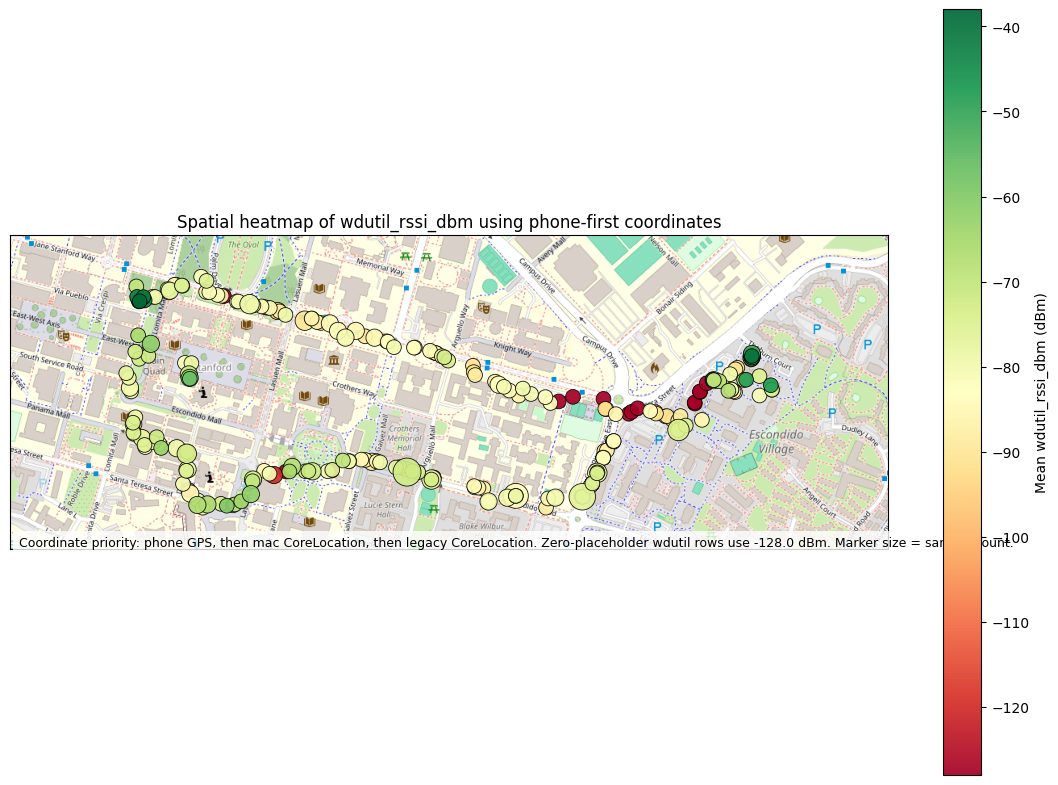

In [3]:
fig, ax, rssi_points = plot_rssi_heatmap(wifi_df)
rows_used = int(rssi_points["sample_count"].sum())
print(f"RSSI heatmap uses {len(rssi_points)} unique coordinate bins from {rows_used} rows with both selected coordinates and wdutil_rssi_dbm.")
plt.show()
